# 35_eval_detail_JIW

- 목적: 결합 경보(28번)와 모델 비교(24~26번)의 **평가를 더 자세히** 보인다 — 혼동행렬(세그먼트·창), ROC·PR 곡선, 점수 분포, 임계 안정성, 모델 크기·학습량, 9종 비교표.
- 입력: `data/processed/28_ensemble_scores_real.parquet`(28번 점수 캐시), `results/24~26_*/cv_scores.csv`. **새로 학습하지 않는다.**
- 출력: `figures/35_eval_detail_JIW/`, `results/35_eval_detail_JIW/`(confusion.csv · thresholds_by_fold.csv · model_sizes.csv · comparison_9models.csv)
- 담당: JIW
- 심사 대응: 2번(평가 방법·비교 결과의 상세), 3번(오류 유형별 개수)
- 근거 표기: **[데이터]** 이 노트북 출력

## 읽는 법
- **양성 = 이상.** TP = 잡은 이상, FN = 놓친 이상, FP = 오경보, TN = 정상으로 둔 정상.
- 세그먼트 판정 = 그 세그먼트의 2초 윈도우 중 하나라도 임계 초과. 분모는 윈도우가 있는 세그먼트(정상 452개, 이상 13개; 팀 평가 모듈과 같은 정의).
- group_kfold는 5 fold 합산(모든 세그먼트가 test에 한 번), 시드 3개 평균. time_block은 정상은 4 block 합산, 이상은 매 block 전체가 test에 들어가므로 block 평균(반복 계수 방지).
- **정밀도·F1은 클래스 비율(이상 13 : 정상 452)에 따라 달라진다.** 이 비율은 데이터 구성의 결과이지 현장 비율이 아니므로 주 지표로 쓰지 않고 참고로 본다.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "35_eval_detail_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B
import ensemble_jiw as E
import eval_detail_jiw as D
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
real = pd.read_parquet(paths.DATA_PROCESSED / "28_ensemble_scores_real.parquet")   # 28번이 만든 캐시. 없으면 28번을 먼저 실행
RULES = ["cnn", "mcd", "cnn&mcd", "cnn|mcd"]
print(NB, "점수 행", len(real))

35_eval_detail_JIW 점수 행 12897


## 1. 혼동행렬 — 세그먼트 단위 (현장 운영 단위)

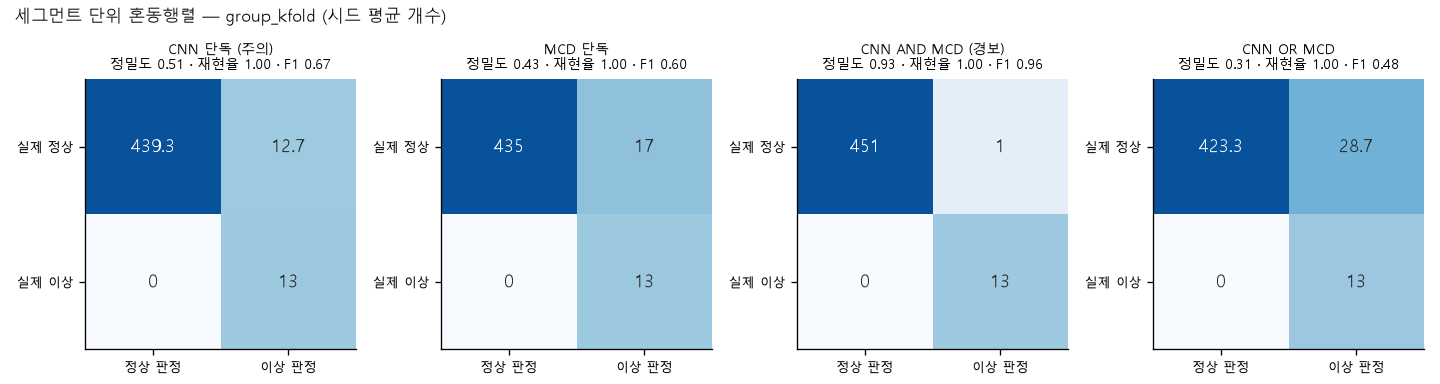

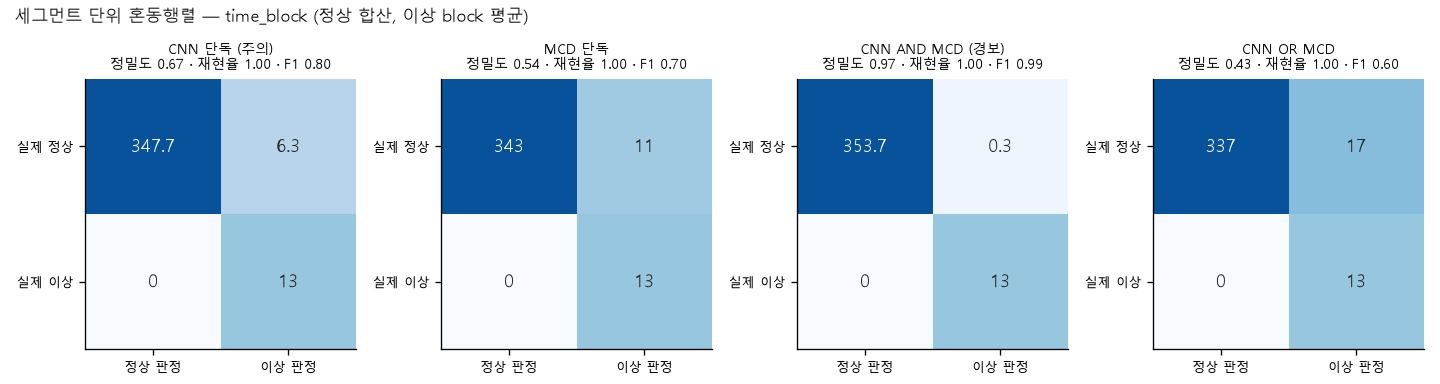

,규칙,단위,분할,TP,FP,FN,TN,정밀도,재현율,특이도,F1,오경보율
0,CNN 단독 (주의),세그먼트,group_kfold_seg,13.0,12.667,0.0,439.333,0.506,1.0,0.972,0.672,0.028
1,MCD 단독,세그먼트,group_kfold_seg,13.0,17.000,0.0,435.000,0.433,1.0,0.962,0.605,0.038
2,CNN AND MCD (경보),세그먼트,group_kfold_seg,13.0,1.000,0.0,451.000,0.929,1.0,0.998,0.963,0.002
3,CNN OR MCD,세그먼트,group_kfold_seg,13.0,28.667,0.0,423.333,0.312,1.0,0.937,0.476,0.063
8,CNN 단독 (주의),세그먼트,time_block,13.0,6.333,0.0,347.667,0.672,1.0,0.982,0.804,0.018
9,MCD 단독,세그먼트,time_block,13.0,11.000,0.0,343.000,0.542,1.0,0.969,0.703,0.031
10,CNN AND MCD (경보),세그먼트,time_block,13.0,0.333,0.0,353.667,0.975,1.0,0.999,0.987,0.001
11,CNN OR MCD,세그먼트,time_block,13.0,17.000,0.0,337.000,0.433,1.0,0.952,0.605,0.048


In [2]:
conf = pd.concat([D.confusion(real, RULES, sp, lv) for sp in ["group_kfold_seg", "time_block"] for lv in ["segment", "window"]], ignore_index=True)
conf.to_csv(RES / "confusion.csv", index=False)
seg = conf[conf["단위"] == "세그먼트"]
D.plot_confusion_grid(seg[seg["분할"] == "group_kfold_seg"], FIG, "세그먼트 단위 혼동행렬 — group_kfold (시드 평균 개수)", "confusion_gkf.png")
D.plot_confusion_grid(seg[seg["분할"] == "time_block"], FIG, "세그먼트 단위 혼동행렬 — time_block (정상 합산, 이상 block 평균)", "confusion_tb.png")
display(Image(FIG / "confusion_gkf.png")); display(Image(FIG / "confusion_tb.png"))
seg.round(3)

## 2. 혼동행렬 — 윈도우 단위

In [3]:
conf[conf["단위"] == "윈도우"].round(3)

,규칙,단위,분할,TP,FP,FN,TN,정밀도,재현율,특이도,F1,오경보율
4,CNN 단독 (주의),윈도우,group_kfold_seg,63.0,33.667,0.0,2220.333,0.652,1.0,0.985,0.789,0.015
5,MCD 단독,윈도우,group_kfold_seg,63.0,22.000,0.0,2232.000,0.741,1.0,0.990,0.851,0.010
6,CNN AND MCD (경보),윈도우,group_kfold_seg,63.0,1.000,0.0,2253.000,0.984,1.0,1.000,0.992,0.000
7,CNN OR MCD,윈도우,group_kfold_seg,63.0,54.667,0.0,2199.333,0.535,1.0,0.976,0.697,0.024
12,CNN 단독 (주의),윈도우,time_block,63.0,14.333,0.0,1715.667,0.815,1.0,0.992,0.898,0.008
13,MCD 단독,윈도우,time_block,63.0,15.000,0.0,1715.000,0.808,1.0,0.991,0.894,0.009
14,CNN AND MCD (경보),윈도우,time_block,63.0,0.333,0.0,1729.667,0.995,1.0,1.000,0.997,0.000
15,CNN OR MCD,윈도우,time_block,63.0,29.000,0.0,1701.000,0.685,1.0,0.983,0.813,0.017


**발견 [데이터]**
- **미탐(FN)은 4개 규칙 모두 0**이다. 이상 세그먼트 13개와 이상 윈도우 63개를 전부 잡는다.
- 규칙 사이의 차이는 **FP(오경보)**다. group_kfold 세그먼트 기준 CNN 단독 12.7개, MCD 단독 17.0개, OR 28.7개, **AND 1.0개**(정상 452개 중). 윈도우 기준 AND는 정상 2,254개 중 1개다.
- 그래서 정밀도가 크게 갈린다(세그먼트 group_kfold: CNN 0.51, AND 0.93). 다만 이상이 13개뿐이라 정밀도·F1은 비율에 민감하다. 같은 오경보 개수라도 이상이 더 많았다면 정밀도는 올라간다.

## 3. ROC · PR 곡선과 점수 분포

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


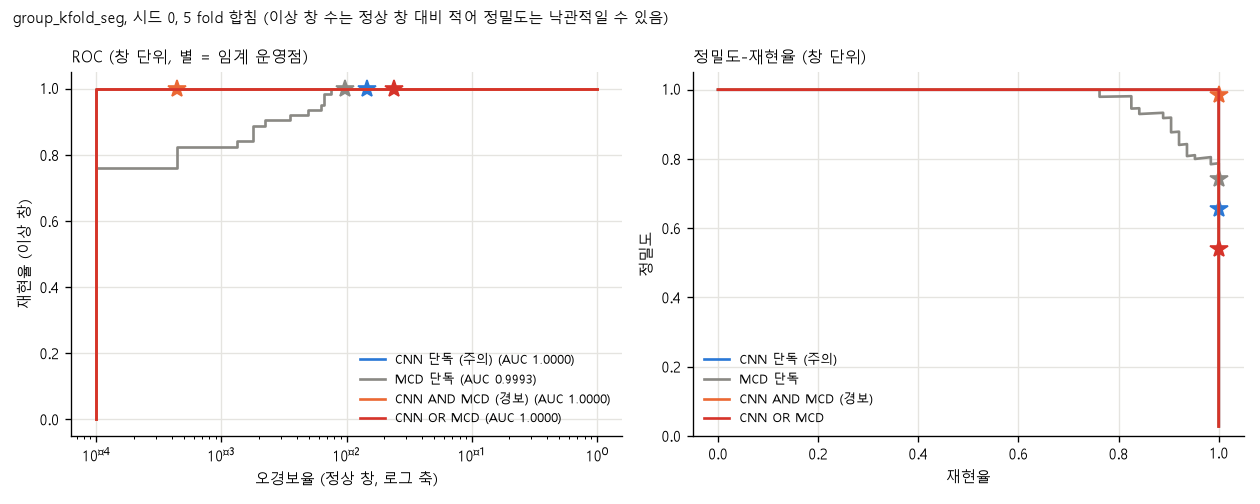

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


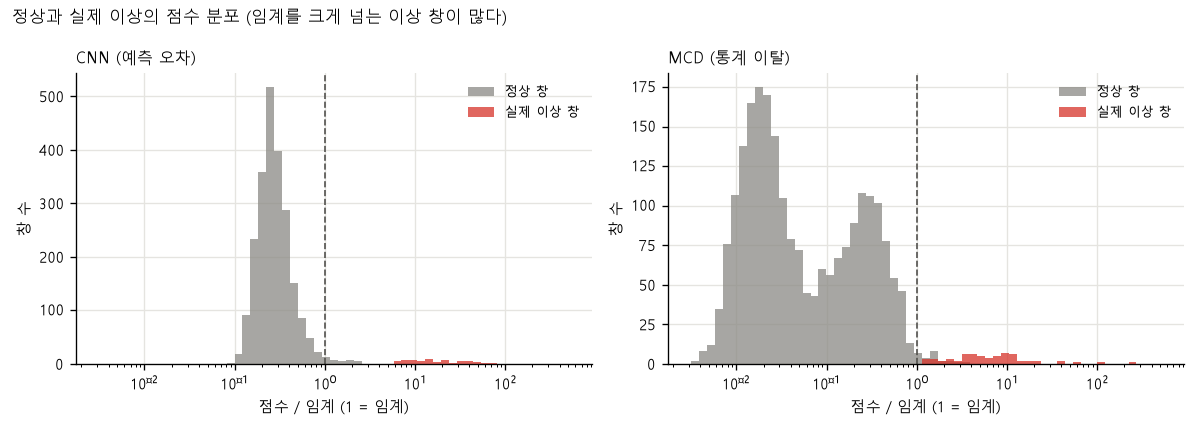

In [4]:
D.plot_roc_pr(real, RULES, FIG); display(Image(FIG / "roc_pr.png"))
D.plot_score_hist(real, FIG); display(Image(FIG / "score_hist.png"))

**발견 [데이터]** ROC는 네 규칙 모두 AUC가 1에 가까워 곡선으로는 구분이 안 된다(x축을 로그로 해야 보인다). 구분은 **임계에서의 운영점(별)**에서 난다: 같은 재현율 1.0에서 AND의 오경보율이 가장 낮다. 점수 분포를 보면 실제 이상 창은 CNN은 대부분 임계의 수 배~수십 배, MCD는 임계 근처(최저 1.2배)에서 시작해 수십 배까지 퍼진다. 정상은 임계 아래에 몰리고 꼬리가 임계를 넘는다.

## 4. 임계 안정성 (train 정상 q99를 fold마다 새로 구함)

In [5]:
th = D.thresholds_by_fold(real)
th.to_csv(RES / "thresholds_by_fold.csv", index=False)
summ = th.groupby("split")[["thr_g_cnn", "thr_g_mcd"]].agg(["min", "median", "max"]).round(2)
summ["MCD 최대/최소"] = (th.groupby("split")["thr_g_mcd"].max() / th.groupby("split")["thr_g_mcd"].min()).round(2)
summ["CNN 최대/최소"] = (th.groupby("split")["thr_g_cnn"].max() / th.groupby("split")["thr_g_cnn"].min()).round(2)
summ

thr_g_cnn              thr_g_mcd                   MCD 최대/최소 CNN 최대/최소
                      min median   max       min   median      max                    
split                                                                                 
group_kfold_seg      3.03   3.53  3.80    615.56  1043.21  1426.55      2.32      1.25
time_block           3.20   3.42  3.72    359.67   424.91   594.97      1.65      1.16

**발견 [데이터]** CNN 임계는 fold마다 안정적이다(최대/최소 1.2배 안팎). **MCD 임계는 fold마다 크게 흔들린다**(group_kfold 616~1,427로 2.3배, time_block 360~595로 1.7배). train 정상에 어떤 세그먼트가 들어가느냐에 따라 마할라노비스 거리의 꼬리가 달라지기 때문이다. 이것이 결합 경보의 임계 안정성에서 가장 큰 불확실성이다.

## 5. 모델 크기와 학습량

In [6]:
sizes = D.model_sizes()
sizes.to_csv(RES / "model_sizes.csv", index=False)
rows = []
segs, W = B.load_inputs()
Wv = W[W["win_s"] == 2.0]
for sp, k, tr, te in B.iter_splits(Wv):
    rows.append({"분할": sp, "fold": k, "train 세그먼트": tr["seg_uid"].nunique(), "학습 시점 수(lookback 5 제외)": sum(len(segs[u]) - 5 for u in tr["seg_uid"].unique()),
                 "train 윈도우": len(tr), "test 정상 세그먼트": te[te.label == 0]["seg_uid"].nunique(), "test 이상 세그먼트": te[te.label == 1]["seg_uid"].nunique(),
                 "test 정상 윈도우": int((te.label == 0).sum()), "test 이상 윈도우": int((te.label == 1).sum())})
split_tab = pd.DataFrame(rows)
display(sizes)
split_tab

,모델,파라미터 수
0,CNN (DeepAnT 변형),7779
1,LSTM-AD,13283
2,MTAD-GAT,5828
3,GDN,481
4,DeepSVDD,3472


,분할,fold,train 세그먼트,학습 시점 수(lookback 5 제외),train 윈도우,test 정상 세그먼트,test 이상 세그먼트,test 정상 윈도우,test 이상 윈도우
0,group_kfold_seg,0,365,13071,1800,87,3,454,20
1,group_kfold_seg,1,363,13049,1801,89,2,453,11
2,group_kfold_seg,2,366,13220,1830,86,2,424,7
3,group_kfold_seg,3,354,12849,1779,98,3,475,16
4,group_kfold_seg,4,360,13035,1806,92,3,448,9
5,time_block,1,98,3684,524,85,13,413,63
6,time_block,2,183,6707,937,87,13,426,63
7,time_block,3,270,9801,1363,91,13,434,63
8,time_block,4,361,13013,1797,91,13,457,63


**발견 [데이터]** 네트워크는 파라미터가 481~13,283개로 아주 작다(정상 학습 시점 약 13,000개). time_block의 첫 fold(k = 1)는 정상 시간대 1 block(약 15분, 98 세그먼트)만으로 학습해서 가장 불리한 설정이다.

## 6. 9종 비교표 (2초 윈도우, fold·시드 평균)

In [7]:
frames = []
for f in ["24_model_forecasting_JIW", "25_model_graph_JIW", "26_model_distribution_JIW"]:
    cv = pd.read_csv(paths.RESULTS / f / "cv_scores.csv")
    frames.append(cv[cv["win_s"] == 2.0])
cv = pd.concat(frames, ignore_index=True)
cv = cv[cv["model"].isin(["CNN (DeepAnT)", "LSTM-AD", "MTAD-GAT", "GDN", "MCD [amp]", "OCSVM [amp]", "HBOS [amp]", "COPOD [amp]", "DeepSVDD"])]
cols = ["auc", "fpr_sample", "fpr_segment", "recall_window", "fpr_high_load", "fpr_low_load", "inj_mean", "sec"]
tab = cv.groupby(["model", "split"], sort=False)[cols].mean().round(3).unstack("split")
tab.to_csv(RES / "comparison_9models.csv")
tab

auc                 fpr_sample                fpr_segment              recall_window              fpr_high_load               fpr_low_load                   inj_mean             \
split         group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block   
model                                                                                                                                                                                                        
CNN (DeepAnT)           1.000      1.000           0.015      0.008           0.028      0.018           1.000      1.000           0.032      0.022           0.001      0.000           0.303      0.314   
LSTM-AD                 1.000      1.000           0.015      0.009           0.026      0.017           1.000      1.000           0.032      0.026           0.000      0.000           0.295      0.282   
MTAD-GAT                1.000      1.000           0.012      0.014           0.022      0.025           1.000      1.000           0.027      0.035           0.000      0.000           0.311      0.299   
GDN                     1.000      0.999           0.012      0.014           0.032      0.041           1.000      0.985           0.027      0.035           0.000      0.000           0.261      0.227   
MCD [amp]               1.000      1.000           0.010      0.008           0.038      0.031           1.000      1.000           0.023      0.003           0.000      0.009           0.086      0.122   
OCSVM [amp]             1.000      1.000           0.023      0.035           0.076      0.103           1.000      1.000           0.021      0.039           0.025      0.033           0.226      0.236   
HBOS [amp]              0.989      0.990           0.012      0.012           0.044      0.040           0.867      0.893           0.025      0.029           0.002      0.004           0.102      0.099   
COPOD [amp]             0.996      0.990           0.007      0.002           0.020      0.009           0.920      0.702           0.016      0.005           0.000      0.000           0.045      0.067   
DeepSVDD                0.958      0.958           0.032      0.056           0.100      0.178           0.830      0.841           0.037      0.030           0.026      0.070           0.158      0.198   

                          sec             
split         group_kfold_seg time_block  
model                                     
CNN (DeepAnT)           4.260      4.133  
LSTM-AD                 8.813      7.133  
MTAD-GAT               14.747     10.358  
GDN                     4.973      3.433  
MCD [amp]              21.240     21.475  
OCSVM [amp]             0.100      0.100  
HBOS [amp]              0.100      0.100  
COPOD [amp]             0.100      0.100  
DeepSVDD                0.133      0.175

**발견 [데이터]** 9종 모두 AUC가 높아(0.96~1.00) 실제 이상으로는 변별력이 없다. 갈리는 지표는 오경보(`fpr_segment`, 고부하 오경보)와 합성 이상 탐지(`inj_mean`)다. DeepSVDD는 AUC·오경보 모두 불안정하다. `sec`는 fold당 학습+평가 시간(초)이며 MCD [amp]의 값이 큰 것은 첫 호출 오버헤드가 섞인 것으로 보인다 [추정].

## 7. 해석

설명과 표는 `docs/modeling_detail_JIW.md`에 정리했다.